In [1]:
#libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA
from tqdm import tqdm
import gudhi

#data
FILE = "COVID-19-transport-use-statistics.ods"

#setup
# Embedding parameters (Perea-Harer: d * tau = period; weekly period = 7)
DIM = 7
DELAY = 1
ROLLING_DAYS = 56            # 8 weeks per analysis window
NOISE_THRESHOLD = 0.10       # H1 features below 10% of max are noise

In [2]:
#load and locate data
SHEET = "Transport_use_(GB)"
HEADER_ROW = 4

df = pd.read_excel(FILE, sheet_name=SHEET, header=HEADER_ROW, engine='odf')
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Shape: (2235, 14)
Columns: ['Date[note 1]', 'Weekday', 'Cars[note 2]', 'Light Commercial Vehicles[note 2]', 'Heavy Goods Vehicles[note 2]', 'All motor vehicles[note 2]', 'National Rail[notes 3,13, 15, 16, 17, 21, 23]', 'National Rail excluding Elizabeth Line [note 13, 21]', 'Transport for London Tube[note 4, 20]', 'Transport for London Bus[notes 4,7, 20]', 'Bus (excluding London)[notes 5,11]', 'Cycling[notes 6,12,18]', 'Notes on data by day', 'Contextual notes by day']


In [3]:
#rail data
DATE_COL = 'Date[note 1]'
RAIL_FULL = 'National Rail[notes 3,13, 15, 16, 17, 21, 23]'
RAIL_EXCL = 'National Rail excluding Elizabeth Line [note 13, 21]'

work = df[[DATE_COL, RAIL_FULL]].rename(
    columns={DATE_COL: 'date', RAIL_FULL: 'rail_full'}
)
if RAIL_EXCL in df.columns:
    work['rail_excl_el'] = df[RAIL_EXCL].values

work['date'] = pd.to_datetime(work['date'], errors='coerce')
for c in ['rail_full', 'rail_excl_el']:
    if c in work.columns:
        work[c] = pd.to_numeric(work[c], errors='coerce')

work = (work.dropna(subset=['date'])
            .drop_duplicates(subset='date')
            .sort_values('date')
            .reset_index(drop=True))

if 'rail_excl_el' in work.columns:
    work['rail'] = work['rail_excl_el'].fillna(work['rail_full'])
else:
    work['rail'] = work['rail_full']

rail = work[['date', 'rail']].dropna(subset=['rail']).reset_index(drop=True)
rail['rail'] = rail['rail'] * 100   # proportions → percentages

print(f"Date range: {rail['date'].min().date()} → {rail['date'].max().date()}")
print(f"N observations: {len(rail)}")

Date range: 2020-03-01 → 2026-04-05
N observations: 2115


In [4]:
#Reindex to complete daily, linearly interpolate, flag imputed
full_idx = pd.date_range(start=rail['date'].min(), end=rail['date'].max(), freq='D')
rail = rail.set_index('date').reindex(full_idx)
rail.index.name = 'date'
rail['imputed'] = rail['rail'].isna()
rail['rail'] = rail['rail'].interpolate(method='linear')
rail = rail.reset_index()

print(f"Complete daily series: {len(rail)} observations")
print(f"Imputed: {rail['imputed'].sum()} ({100*rail['imputed'].mean():.1f}%)")

Complete daily series: 2227 observations
Imputed: 112 (5.0%)


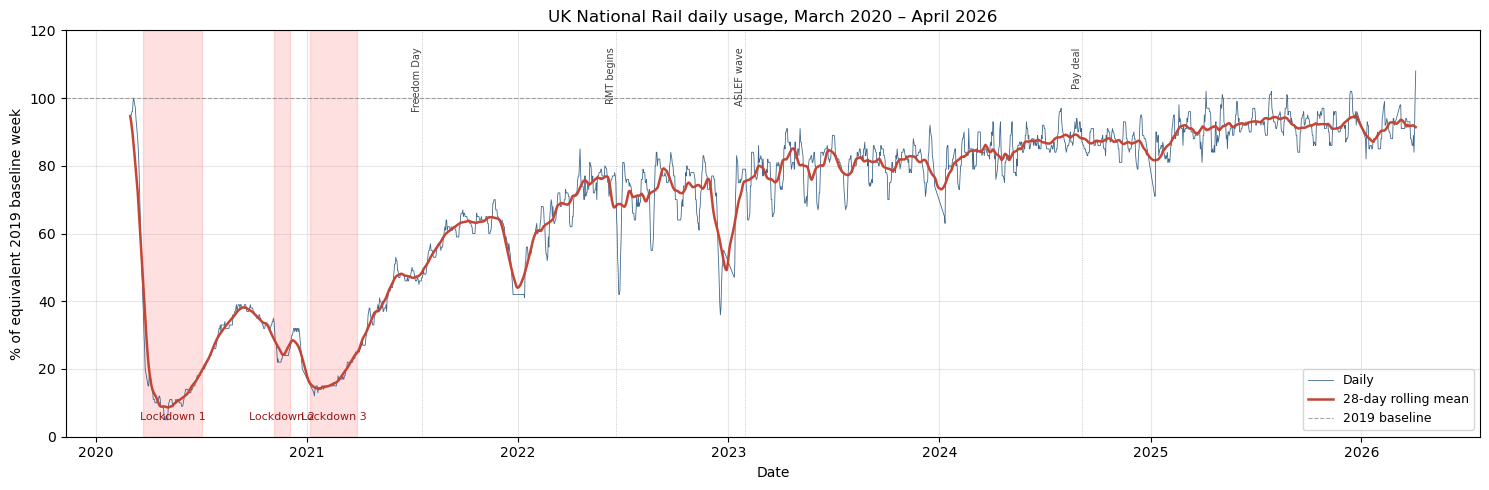

In [5]:
#Figure 1: full time series with regime annotations
LOCKDOWNS = [
    ('2020-03-23', '2020-07-04', 'Lockdown 1'),
    ('2020-11-05', '2020-12-02', 'Lockdown 2'),
    ('2021-01-06', '2021-03-29', 'Lockdown 3'),
]
EVENTS = {
    '2021-07-19': 'Freedom Day',
    '2022-06-21': 'RMT begins',
    '2023-01-30': 'ASLEF wave',
    '2024-09-04': 'Pay deal',
}

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(rail['date'], rail['rail'], lw=0.6, color='#1f4e79', alpha=0.85, label='Daily')
roll = rail.set_index('date')['rail'].rolling('28D', center=True).mean()
ax.plot(roll.index, roll.values, lw=1.8, color='#c44536', label='28-day rolling mean')
ax.axhline(100, color='grey', lw=0.8, ls='--', alpha=0.7, label='2019 baseline')

for s, e, label in LOCKDOWNS:
    ax.axvspan(s, e, alpha=0.12, color='red')
    mid = pd.to_datetime(s) + (pd.to_datetime(e) - pd.to_datetime(s)) / 2
    ax.annotate(label, xy=(mid, 5), fontsize=8, ha='center', color='darkred', alpha=0.9)

for date, label in EVENTS.items():
    d = pd.to_datetime(date)
    ax.axvline(d, color='black', lw=0.5, alpha=0.35, ls=':')
    ax.annotate(label, xy=(d, 115), rotation=90, fontsize=7,
                ha='right', va='top', alpha=0.75)

ax.set_xlabel('Date'); ax.set_ylabel('% of equivalent 2019 baseline week')
ax.set_title('UK National Rail daily usage, March 2020 – April 2026', fontsize=12)
ax.set_ylim(0, 120)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(True, alpha=0.3); ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('fig1_timeseries.png', dpi=200, bbox_inches='tight')
plt.show()

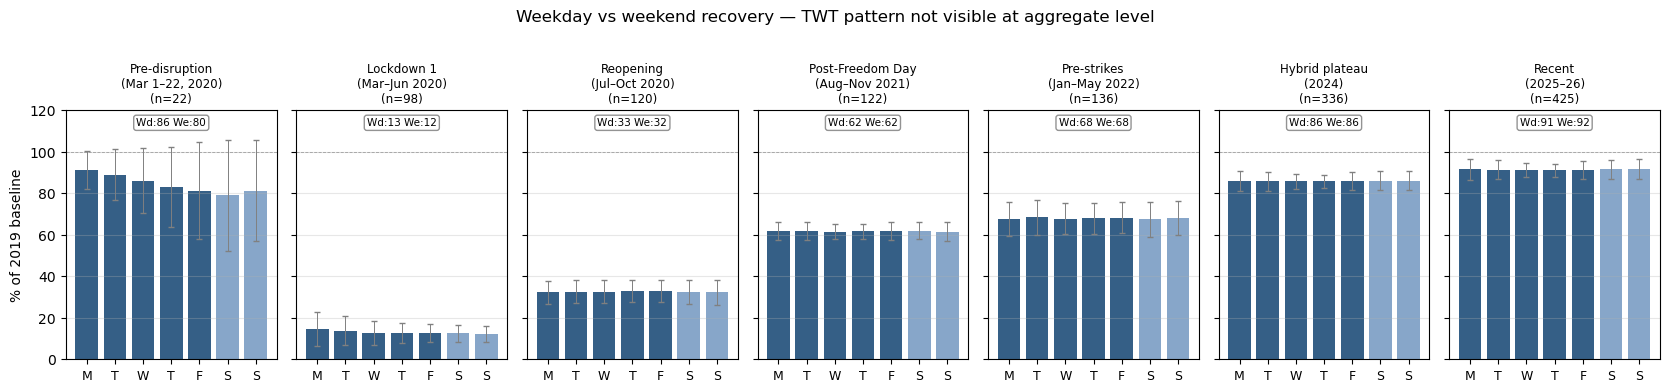

In [6]:
#Figure 2: weekly profile by regime (supports no-TWT finding)
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
rail['dow'] = rail['date'].dt.day_name()

regimes = {
    'Pre-disruption\n(Mar 1–22, 2020)':  ('2020-03-01', '2020-03-22'),
    'Lockdown 1\n(Mar–Jun 2020)':         ('2020-03-23', '2020-06-30'),
    'Reopening\n(Jul–Oct 2020)':          ('2020-07-04', '2020-10-31'),
    'Post-Freedom Day\n(Aug–Nov 2021)':   ('2021-08-01', '2021-11-30'),
    'Pre-strikes\n(Jan–May 2022)':        ('2022-01-15', '2022-05-31'),
    'Hybrid plateau\n(2024)':             ('2024-01-15', '2024-12-15'),
    'Recent\n(2025–26)':                  ('2025-01-15', '2026-04-05'),
}

fig, axes = plt.subplots(1, len(regimes), figsize=(2.4*len(regimes), 3.8), sharey=True)
for ax, (name, (s, e)) in zip(axes, regimes.items()):
    sub = rail[(rail['date'] >= s) & (rail['date'] <= e) & (~rail['imputed'])]
    means = sub.groupby('dow')['rail'].mean().reindex(dow_order)
    sds   = sub.groupby('dow')['rail'].std().reindex(dow_order)
    colors = ['#1f4e79']*5 + ['#7a9cc4']*2
    ax.bar(range(7), means.values, color=colors, alpha=0.9,
           yerr=sds.values, ecolor='grey', capsize=2, error_kw={'lw': 0.7})
    ax.set_xticks(range(7))
    ax.set_xticklabels([d[:1] for d in dow_order], fontsize=9)
    ax.set_title(f'{name}\n(n={len(sub)})', fontsize=8.5)
    ax.axhline(100, color='grey', ls='--', lw=0.6, alpha=0.7)
    ax.set_ylim(0, 120); ax.grid(True, alpha=0.3, axis='y')
    wd = means.iloc[:5].mean(); we = means.iloc[5:].mean()
    ax.text(0.5, 0.97, f'Wd:{wd:.0f} We:{we:.0f}',
            transform=ax.transAxes, fontsize=7.5, va='top', ha='center',
            bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='grey', alpha=0.85))
axes[0].set_ylabel('% of 2019 baseline')
plt.suptitle('Weekday vs weekend recovery — TWT pattern not visible at aggregate level', y=1.02)
plt.tight_layout()
plt.savefig('fig2_weekly_profile.png', dpi=200, bbox_inches='tight')
plt.show()

In [7]:
#core TDA helpers
def takens_embedding(x, dim=DIM, delay=DELAY):
    x = np.asarray(x, dtype=float)
    n_points = len(x) - (dim - 1) * delay
    return np.column_stack([x[i*delay : i*delay + n_points] for i in range(dim)])

def lag_acf(x, lag=7):
    x = np.asarray(x, dtype=float)
    if len(x) <= lag:
        return 0.0
    a = x[:-lag] - x[:-lag].mean()
    b = x[lag:]  - x[lag:].mean()
    denom = np.sqrt((a**2).sum() * (b**2).sum())
    return float((a * b).sum() / denom) if denom > 0 else 0.0

def compute_h1(point_cloud):
    max_edge = pdist(point_cloud).max()
    rips = gudhi.RipsComplex(points=point_cloud, max_edge_length=max_edge)
    st = rips.create_simplex_tree(max_dimension=2)
    diag = st.persistence()
    h0 = np.array([(b, d) for dm, (b, d) in diag if dm == 0 and np.isfinite(d)])
    h1 = np.array([(b, d) for dm, (b, d) in diag if dm == 1])
    return diag, h0, h1

def summarise_window(x, noise_frac=NOISE_THRESHOLD):
    pc = takens_embedding(x)
    _, _, h1 = compute_h1(pc)
    out = {'std': float(np.std(x)), 'mean': float(np.mean(x))}
    if len(h1) == 0:
        out.update({'max_h1': 0.0, 'sum_h1': 0.0, 'entropy_h1': 0.0, 'n_significant': 0})
        return out
    persistences = h1[:, 1] - h1[:, 0]
    persistences = persistences[persistences > 0]
    if len(persistences) == 0:
        out.update({'max_h1': 0.0, 'sum_h1': 0.0, 'entropy_h1': 0.0, 'n_significant': 0})
        return out
    p_max = persistences.max()
    p_sum = persistences.sum()
    p_norm = persistences / p_sum
    entropy = float(-np.sum(p_norm * np.log(p_norm)))
    n_sig = int((persistences > noise_frac * p_max).sum())
    out.update({'max_h1': float(p_max), 'sum_h1': float(p_sum),
                'entropy_h1': entropy, 'n_significant': n_sig})
    return out

In [8]:
#TDA rolling pipeline + ACF comparator
results = []
for i in tqdm(range(len(rail) - ROLLING_DAYS + 1)):
    window = rail.iloc[i : i + ROLLING_DAYS]
    x = window['rail'].values
    stats = summarise_window(x)
    stats['centre_date'] = window['date'].iloc[ROLLING_DAYS // 2]
    stats['imputed_frac'] = window['imputed'].mean()
    stats['acf_lag7'] = lag_acf(x, lag=7)
    results.append(stats)

tda_df = pd.DataFrame(results)
print(f"Computed {len(tda_df)} rolling summaries")
print(tda_df[['std','sum_h1','entropy_h1','n_significant','acf_lag7']].describe().round(3))
tda_df.to_csv('tda_rolling_summary.csv', index=False)

100%|██████████| 2172/2172 [00:29<00:00, 74.29it/s]

Computed 2172 rolling summaries
            std    sum_h1  entropy_h1  n_significant  acf_lag7
count  2172.000  2172.000    2172.000       2172.000  2172.000
mean      5.150    10.814       1.337          4.569     0.077
std       3.160     7.811       0.703          3.287     0.447
min       1.028     0.000      -0.000          0.000    -0.733
25%       3.442     5.127       0.782          2.000    -0.267
50%       4.481    10.045       1.445          4.000    -0.033
75%       5.836    14.251       1.863          7.000     0.446
max      35.607    49.342       2.757         17.000     0.980


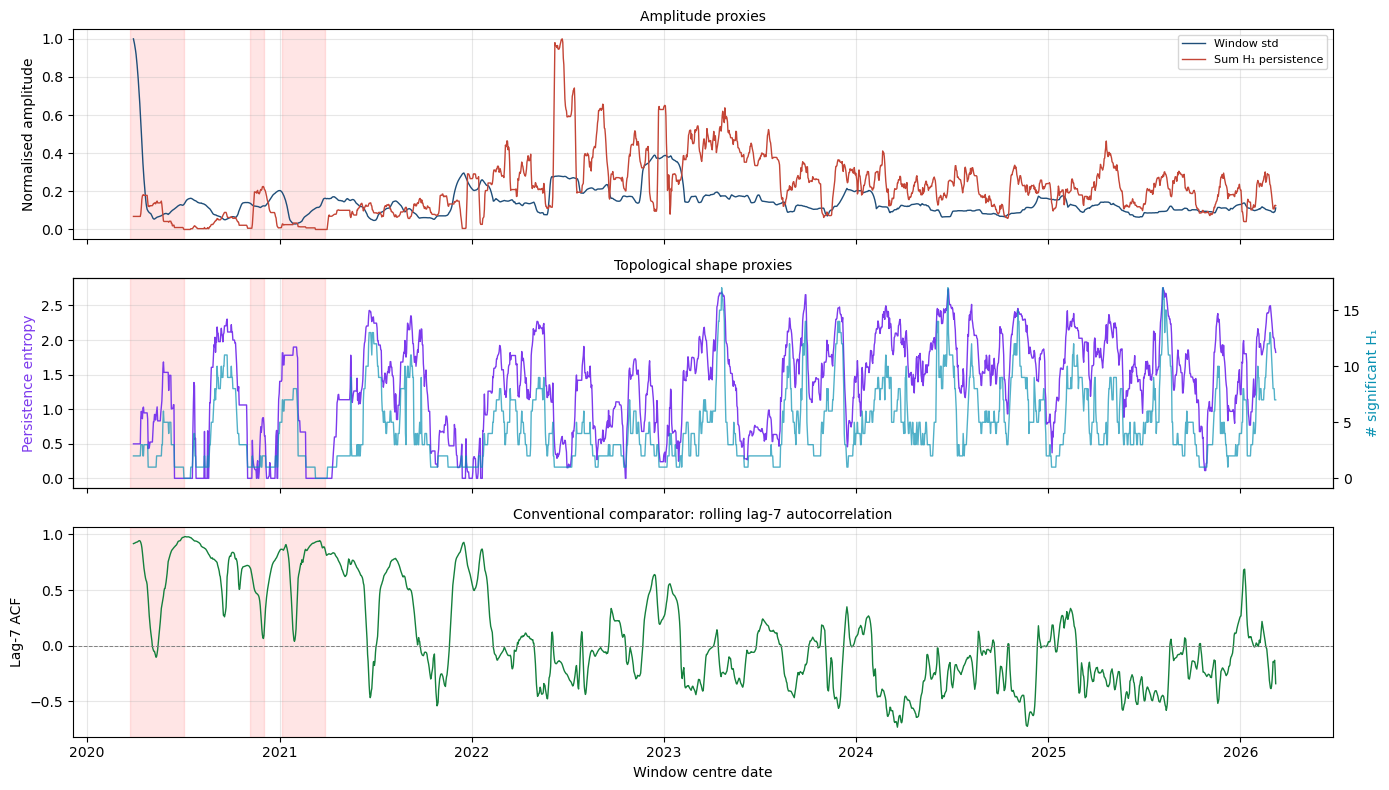

In [9]:
#Figure 3: rolling topological summaries vs ACF (3-panel)
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

# Panel 1: amplitude (std and sum_h1, normalised)
ax = axes[0]
ax.plot(tda_df['centre_date'], tda_df['std'] / tda_df['std'].max(),
        lw=1, color='#1f4e79', label='Window std')
ax.plot(tda_df['centre_date'], tda_df['sum_h1'] / tda_df['sum_h1'].max(),
        lw=1, color='#c44536', label='Sum H₁ persistence')
ax.set_ylabel('Normalised amplitude')
ax.set_title('Amplitude proxies', fontsize=10)
ax.legend(loc='upper right', fontsize=8); ax.grid(True, alpha=0.3)

# Panel 2: shape (entropy + significant feature count, twin axes)
ax = axes[1]; ax2 = ax.twinx()
ax.plot(tda_df['centre_date'], tda_df['entropy_h1'], lw=1, color='#7c3aed')
ax2.plot(tda_df['centre_date'], tda_df['n_significant'], lw=1, color='#0891b2', alpha=0.7)
ax.set_ylabel('Persistence entropy', color='#7c3aed')
ax2.set_ylabel('# significant H₁', color='#0891b2')
ax.set_title('Topological shape proxies', fontsize=10); ax.grid(True, alpha=0.3)

# Panel 3: ACF
ax = axes[2]
ax.plot(tda_df['centre_date'], tda_df['acf_lag7'], lw=1, color='#15803d')
ax.axhline(0, color='grey', lw=0.7, ls='--')
ax.set_ylabel('Lag-7 ACF')
ax.set_title('Conventional comparator: rolling lag-7 autocorrelation', fontsize=10)
ax.grid(True, alpha=0.3)

for ax in axes:
    for s, e, _ in LOCKDOWNS:
        ax.axvspan(s, e, alpha=0.10, color='red')

axes[-1].set_xlabel('Window centre date')
axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('fig3_rolling_summaries.png', dpi=200, bbox_inches='tight')
plt.show()

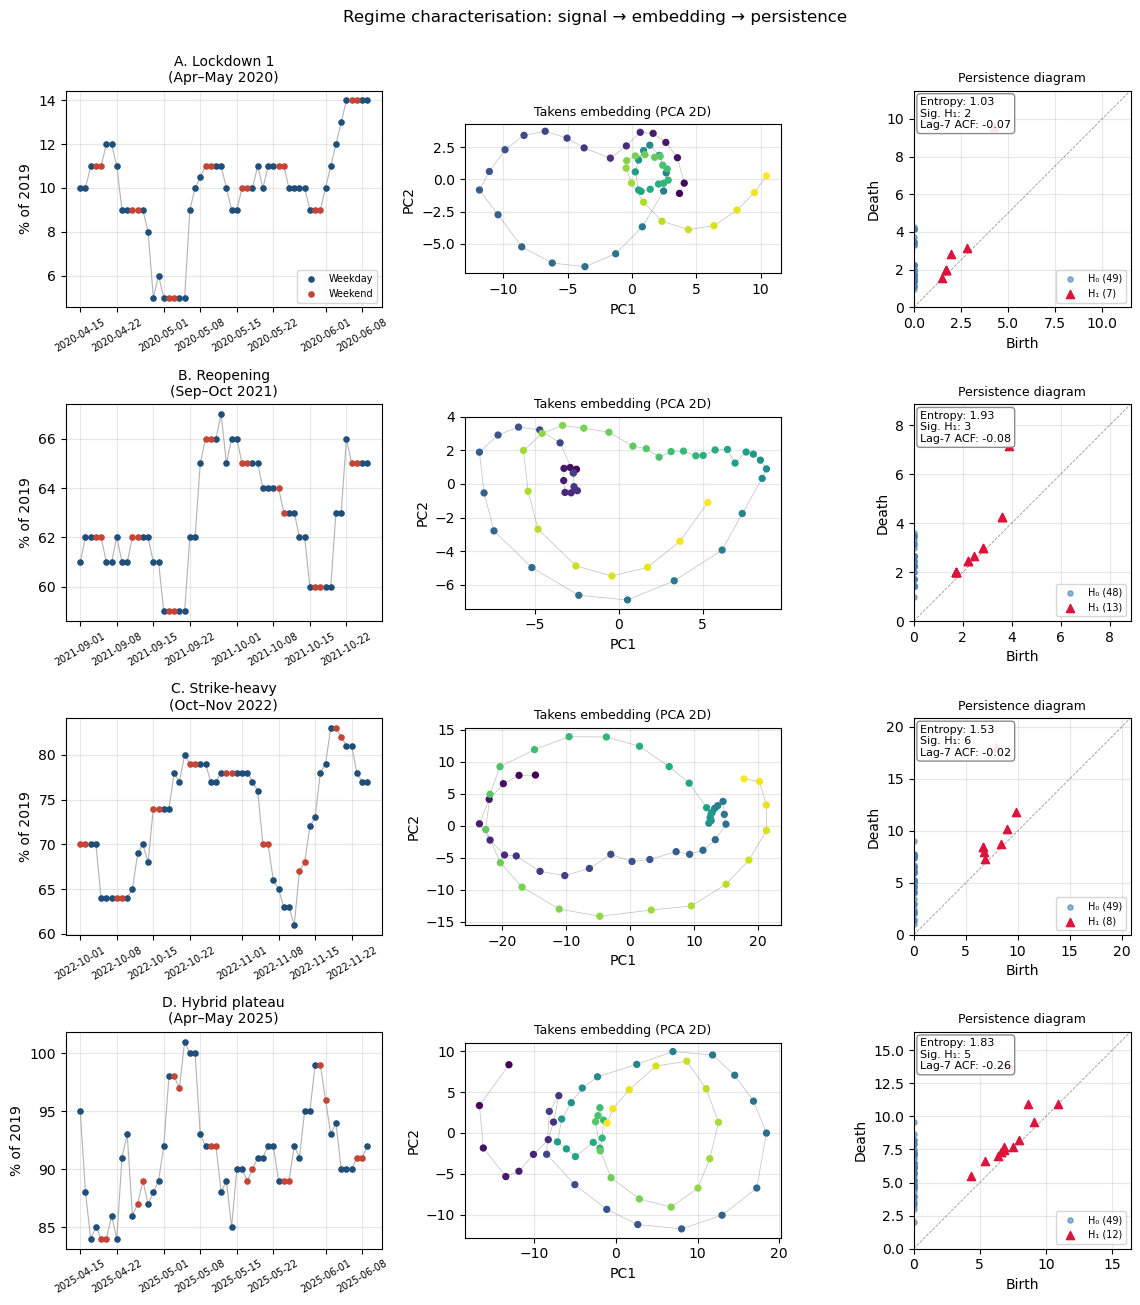

In [10]:
#Figure 4: regime characterisation (4 windows × 3 columns)
representative_windows = {
    'A. Lockdown 1\n(Apr–May 2020)':         '2020-04-15',
    'B. Reopening\n(Sep–Oct 2021)':          '2021-09-01',
    'C. Strike-heavy\n(Oct–Nov 2022)':       '2022-10-01',
    'D. Hybrid plateau\n(Apr–May 2025)':     '2025-04-15',
}

fig, axes = plt.subplots(4, 3, figsize=(12, 13))

for row, (name, start) in enumerate(representative_windows.items()):
    sub = rail[rail['date'] >= pd.to_datetime(start)].head(ROLLING_DAYS).reset_index(drop=True)
    x = sub['rail'].values
    is_we = sub['date'].dt.dayofweek.values >= 5

    ax = axes[row, 0]
    ax.plot(sub['date'], x, lw=0.8, color='grey', alpha=0.6, zorder=1)
    ax.scatter(sub['date'][~is_we], x[~is_we], c='#1f4e79', s=14, label='Weekday', zorder=2)
    ax.scatter(sub['date'][is_we],  x[is_we],  c='#c44536', s=14, label='Weekend', zorder=2)
    ax.set_title(name, fontsize=10); ax.set_ylabel('% of 2019')
    ax.grid(True, alpha=0.3); ax.tick_params(axis='x', rotation=30, labelsize=7)
    if row == 0: ax.legend(loc='lower right', fontsize=7)

    pc = takens_embedding(x)
    pc_2d = PCA(n_components=2).fit_transform(pc)
    ax = axes[row, 1]
    ax.plot(pc_2d[:, 0], pc_2d[:, 1], '-', lw=0.5, color='gray', alpha=0.5)
    ax.scatter(pc_2d[:, 0], pc_2d[:, 1], c=range(len(pc_2d)), cmap='viridis', s=18, zorder=3)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.set_title('Takens embedding (PCA 2D)', fontsize=9)
    ax.grid(True, alpha=0.3); ax.set_aspect('equal')

    _, h0, h1 = compute_h1(pc)
    ax = axes[row, 2]
    if len(h0):
        ax.scatter(h0[:, 0], h0[:, 1], c='steelblue', s=14, alpha=0.6, label=f'H₀ ({len(h0)})')
    if len(h1):
        ax.scatter(h1[:, 0], h1[:, 1], c='crimson', s=35, marker='^',
                   label=f'H₁ ({len(h1)})', zorder=3)
    upper = max(h0[:, 1].max() if len(h0) else 0,
                h1[:, 1].max() if len(h1) else 0) * 1.1 + 1
    ax.plot([0, upper], [0, upper], 'k--', alpha=0.4, lw=0.6)
    ax.set_xlim(0, upper); ax.set_ylim(0, upper)
    ax.set_xlabel('Birth'); ax.set_ylabel('Death')
    ax.set_title('Persistence diagram', fontsize=9)
    ax.legend(loc='lower right', fontsize=7)
    ax.grid(True, alpha=0.3); ax.set_aspect('equal')

    if len(h1):
        persistences = h1[:, 1] - h1[:, 0]
        p_norm = persistences / persistences.sum()
        entropy = float(-np.sum(p_norm * np.log(p_norm)))
        n_sig = int((persistences > 0.10 * persistences.max()).sum())
        acf7 = lag_acf(x, lag=7)
        ax.text(0.03, 0.97,
                f'Entropy: {entropy:.2f}\nSig. H₁: {n_sig}\nLag-7 ACF: {acf7:+.2f}',
                transform=ax.transAxes, fontsize=8, va='top', ha='left',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='grey', alpha=0.9))

plt.suptitle('Regime characterisation: signal → embedding → persistence', y=1.00, fontsize=12)
plt.tight_layout()
plt.savefig('fig4_regime_characterisation.png', dpi=200, bbox_inches='tight')
plt.show()

In [13]:
rail['rail'].describe().round(1)

count    2227.0
mean       68.1
std        25.2
min         5.0
25%        53.0
50%        78.0
75%        87.0
max       108.0
Name: rail, dtype: float64